# Trajectory Analysis Test

## Load Libraries

In [ ]:
from pyVIA.core import *
import pyVIA.datasets_via as datasets_via
import pandas as pd 
import scanpy as sc
# Settings the warnings to be ignored 
import warnings 
warnings.filterwarnings('ignore') 


from IPython.display import Image

/home/gitpod/miniconda3/envs/ViaEnv2/lib/python3.10/site-packages/phate/__init__.py


## Create Directories

In [10]:
!mkdir plots

mkdir: cannot create directory ‘plots’: File exists


## Load Data

In [2]:
adata_counts = datasets_via.toy_multifurcating()
print(adata_counts)
true_label = adata_counts.obs['group_id'].tolist()
ncomps = 30
sc.tl.pca(adata_counts, svd_solver='arpack', n_comps=ncomps)

2025-05-18 13:17:07.180718	Start downloading data...
2025-05-18 13:17:07.416931	Finished downloading data. Saved to ./toy_multifurcating_M8_n1000d1000.csv
AnnData object with n_obs × n_vars = 1000 × 1000
    obs: 'group_id', 'true_time'


## Create Via Object and Run 

In [3]:
#define parameters
ncomps, knn, random_seed, dataset, root_user, memory  =30,20, 42,'toy', ['M1'], 20

v0 = VIA(adata_counts.obsm['X_pca'][:, 0:ncomps], true_label, edgepruning_clustering_resolution=0.15, edgepruning_clustering_resolution_local=1,
             knn=knn, cluster_graph_pruning=1, too_big_factor=0.3, root_user=root_user, preserve_disconnected=True, dataset='group',
             random_seed=random_seed,memory=memory)#, do_compute_embedding=True, embedding_type='via-atlas') #set these options if you wish to run the embedding during the TI computation. embedding_type = 'via-mds' is extremely fast, and useful for a "quick" view
v0.run_VIA()

2025-05-18 13:18:00.994783	Running VIA over input data of 1000 (samples) x 30 (features)
2025-05-18 13:18:00.994843	Knngraph has 20 neighbors
2025-05-18 13:18:01.286008	Finished global pruning of 20-knn graph used for clustering at level of 0.15. Kept 46.7 % of edges. 
2025-05-18 13:18:01.290917	Number of connected components used for clustergraph  is 1
2025-05-18 13:18:01.317528	Commencing community detection
2025-05-18 13:18:01.377723	Finished community detection. Found 43 clusters.
2025-05-18 13:18:01.378370	Merging 30 very small clusters (<10)
2025-05-18 13:18:01.378941	Finished detecting communities. Found 13 communities
2025-05-18 13:18:01.379062	Making cluster graph. Global cluster graph pruning level: 1
2025-05-18 13:18:01.381648	Graph has 1 connected components before pruning
2025-05-18 13:18:01.382963	Graph has 1 connected components after pruning
2025-05-18 13:18:01.383164	Graph has 1 connected components after reconnecting
2025-05-18 13:18:01.383672	0.0% links trimmed from 

  0%|          | 0/1300 [00:00<?, ?it/s]

memory for rw2 hittings times  2. Using rw2 based pt
2025-05-18 13:18:15.425020	Identifying terminal clusters corresponding to unique lineages...
2025-05-18 13:18:15.425046	Closeness:[3, 4, 5, 6, 7, 8, 9, 10]
2025-05-18 13:18:15.425057	Betweenness:[3, 4, 6, 7, 8, 9, 10]
2025-05-18 13:18:15.425064	Out Degree:[0, 3, 4, 6, 7, 8, 9, 10]
2025-05-18 13:18:15.425319	Terminal clusters corresponding to unique lineages in this component are [4, 7, 8, 9, 10] 
2025-05-18 13:18:15.425340	Calculating lineage probability at memory 20


  0%|          | 0/1000 [00:00<?, ?it/s]

2025-05-18 13:18:25.818388	Cluster or terminal cell fate 4 is reached 202.0 times
2025-05-18 13:18:25.846550	Cluster or terminal cell fate 7 is reached 256.0 times
2025-05-18 13:18:25.870470	Cluster or terminal cell fate 8 is reached 477.0 times
2025-05-18 13:18:25.893353	Cluster or terminal cell fate 9 is reached 456.0 times
2025-05-18 13:18:25.916169	Cluster or terminal cell fate 10 is reached 260.0 times
2025-05-18 13:18:25.920770	There are (5) terminal clusters corresponding to unique lineages {4: 'M6', 7: 'M2', 8: 'M5', 9: 'M4', 10: 'M8'}
2025-05-18 13:18:25.920803	Begin projection of pseudotime and lineage likelihood
2025-05-18 13:18:26.053217	Cluster graph layout based on forward biasing
2025-05-18 13:18:26.053926	Starting make edgebundle viagraph...
2025-05-18 13:18:26.053952	Make via clustergraph edgebundle
2025-05-18 13:18:26.410741	Hammer dims: Nodes shape: (13, 2) Edges shape: (26, 3)
2025-05-18 13:18:26.411759	Graph has 1 connected components before pruning
2025-05-18 13:1

## Plot VIA graph

tune edges False


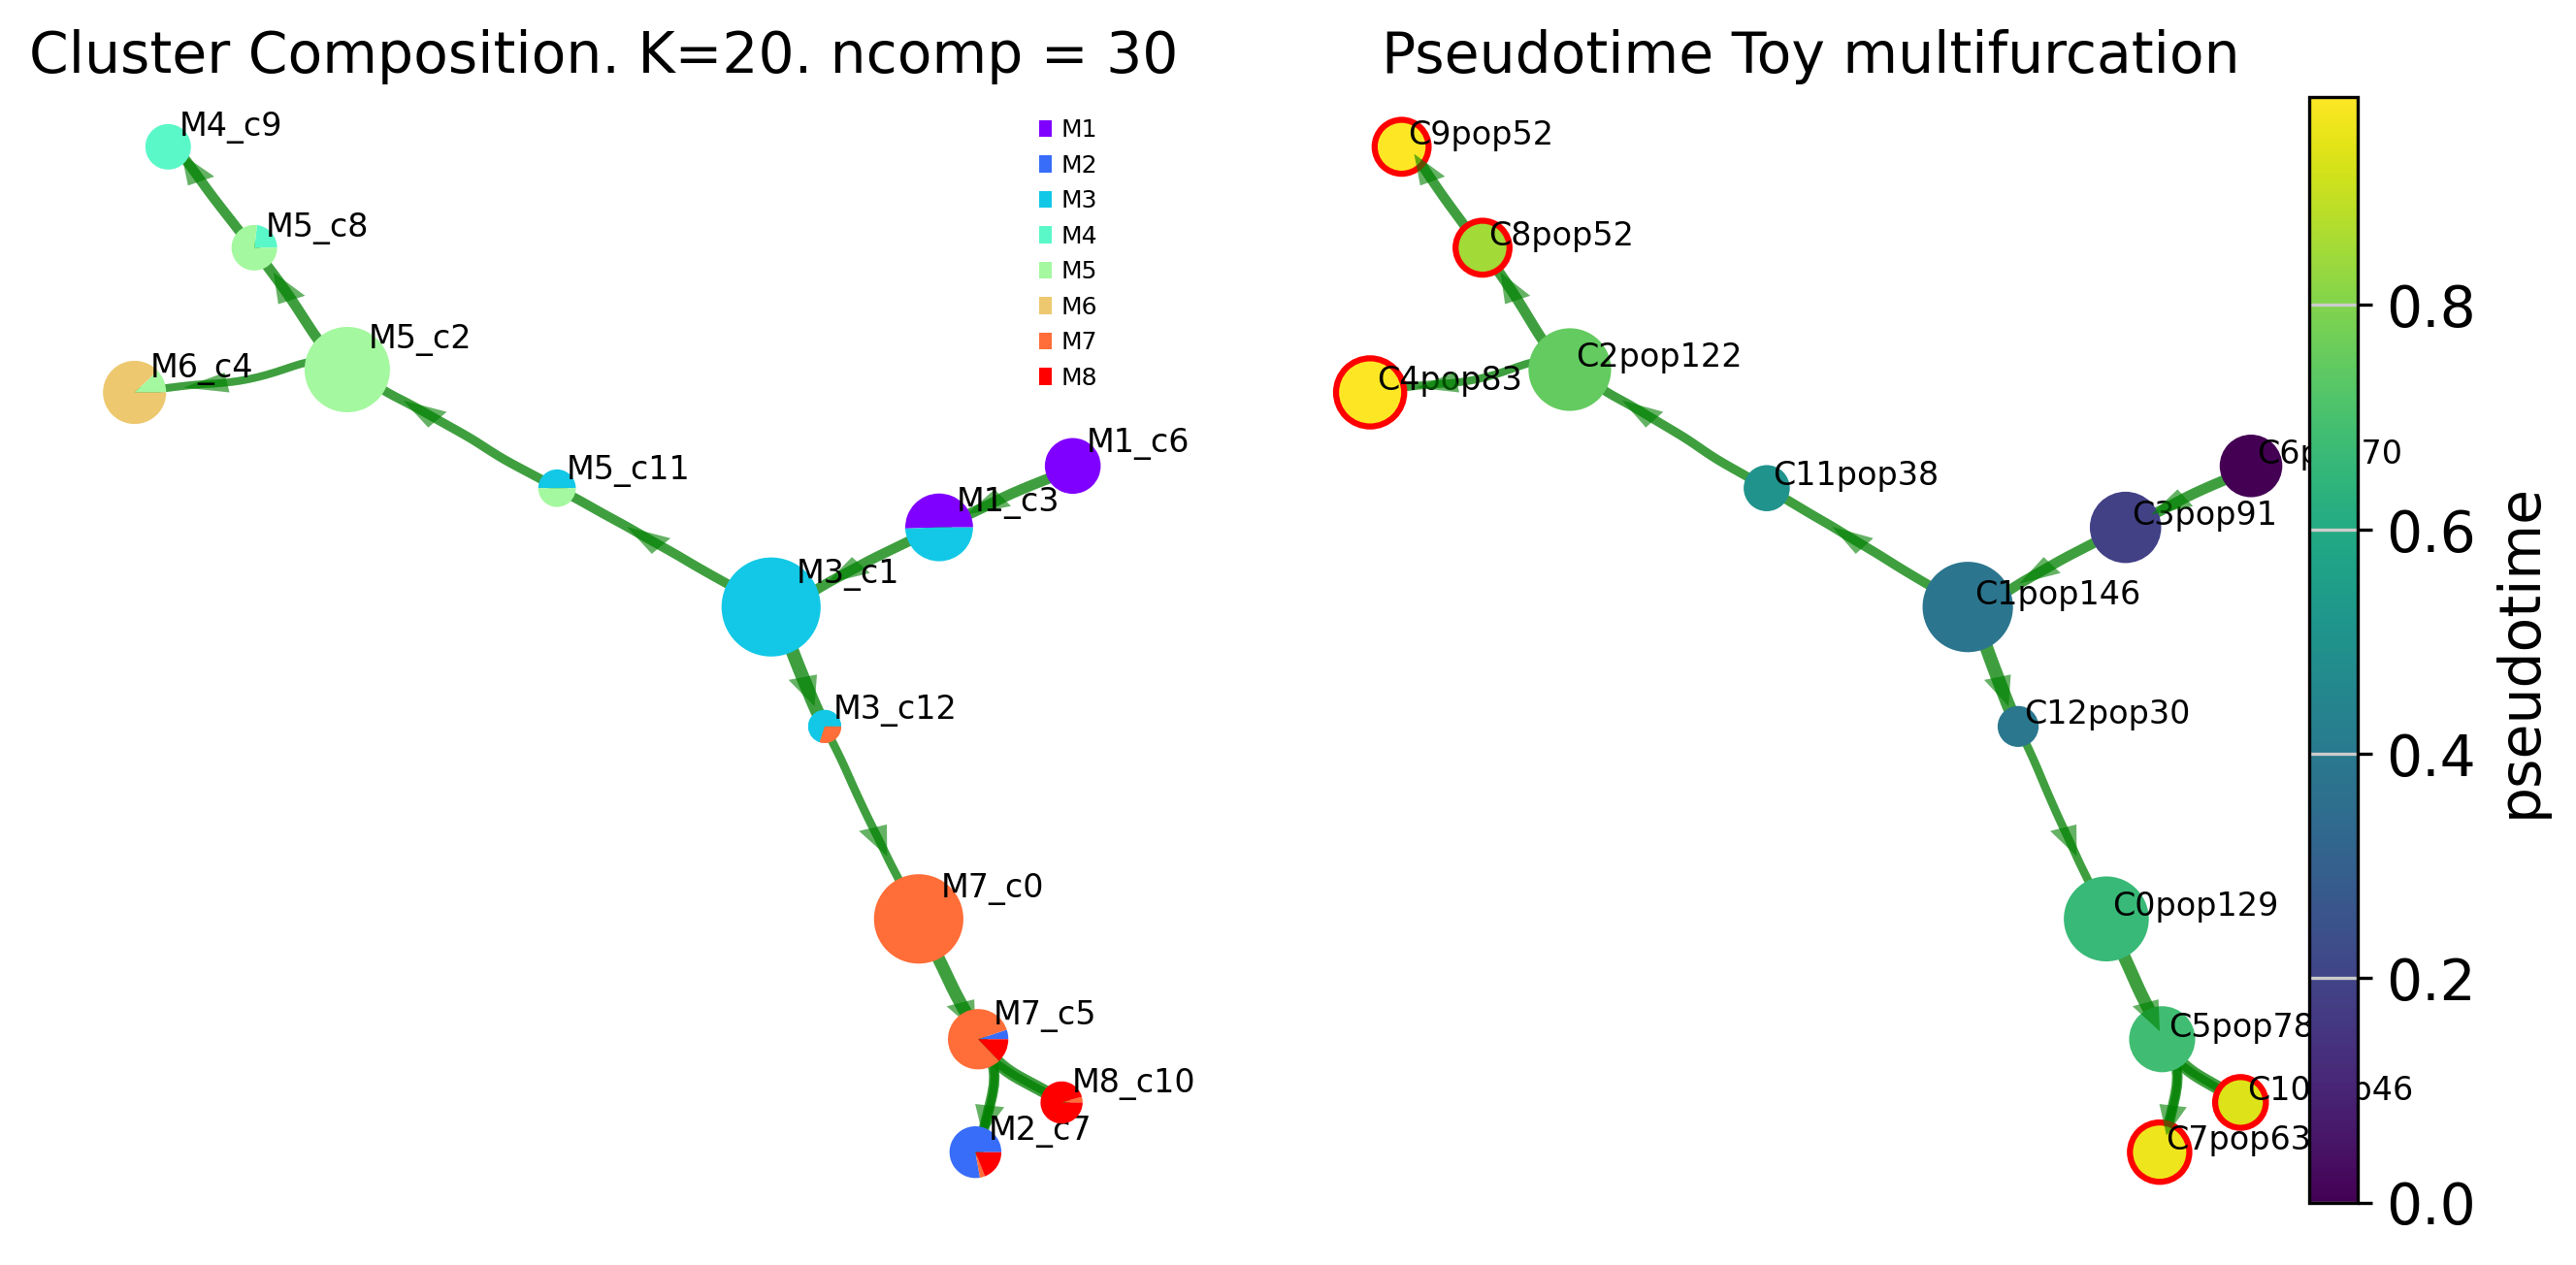

In [4]:
# draw the piechart clustergraph beside a clustergraph colored by the pseudotime ('pt') or gene expression ('gene').
# type_pt: 'pt' automatically takes the cluster level pseudotimes. 'gene' requires user to also pass gene_exp 
# gene_exp =''. In order to plot gene intensity, a list of cluster level gene/feature values should be provided as a list
# cmap = None. Can be specified and influences the cmap of the pt/gene graph
# ax_text = True. Can set to false if you don't want the cluster and populations labels 
# other features like edge width, color, alpha can be set here too
# Terminal lineage clusters have red outline (in rhs graph)
fig, ax, ax2= plot_piechart_viagraph(via_object=v0, type_data='pt', title='Toy multifurcation', cmap='viridis', ax_text=True, gene_exp='', alpha_edge=0.5, linewidth_edge=1.5, edge_color='green', headwidth_arrow=0.2)
fig.set_size_inches(10,5)

## Creating Via Atlas Embeddings

X-input (1000, 30)
len membership and n_cells 1000 1000
n cell 1000
2025-05-18 13:19:23.637265	Computing embedding on sc-Viagraph
2025-05-18 13:19:23.637621	using via cluster graph to initialize embedding


  0%|          | 0/100 [00:00<?, ?it/s]

	completed  0  /  100 epochs
	completed  10  /  100 epochs
	completed  20  /  100 epochs
	completed  30  /  100 epochs
	completed  40  /  100 epochs
	completed  50  /  100 epochs
	completed  60  /  100 epochs
	completed  70  /  100 epochs
	completed  80  /  100 epochs
	completed  90  /  100 epochs


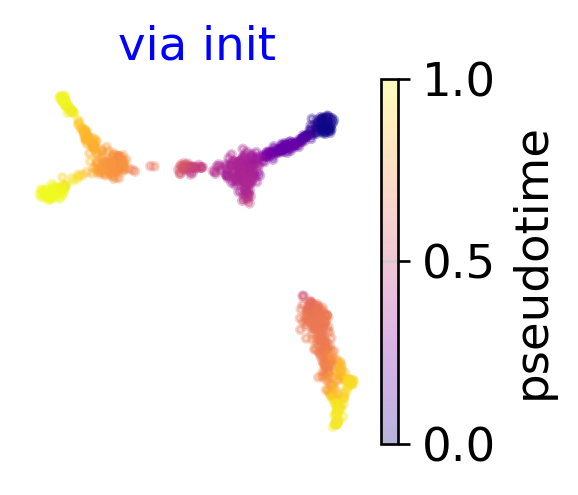

In [5]:
em2 = via_atlas_emb(via_object=v0,init_pos='via')
# optionally use UMAP/Phate/tsne 
# embedding = umap.UMAP().fit_transform(adata_counts.obsm['X_pca'][:, 0:10]) #if you wish, you can use a precomputed embedding (umap, t-sne)

f,ax=plot_scatter(embedding=em2, labels=v0.single_cell_pt_markov, cmap = 'plasma', title='via init')
f.set_size_inches(2,2)

## Run VIA MDS

X-input (1000, 30)
len membership and n_cells 1000 1000
n cell 1000
2025-05-18 13:20:01.378504	Computing embedding on sc-Viagraph
2025-05-18 13:20:01.378875	using via cluster graph to initialize embedding


  0%|          | 0/100 [00:00<?, ?it/s]

	completed  0  /  100 epochs
	completed  10  /  100 epochs
	completed  20  /  100 epochs
	completed  30  /  100 epochs
	completed  40  /  100 epochs
	completed  50  /  100 epochs
	completed  60  /  100 epochs
	completed  70  /  100 epochs
	completed  80  /  100 epochs
	completed  90  /  100 epochs


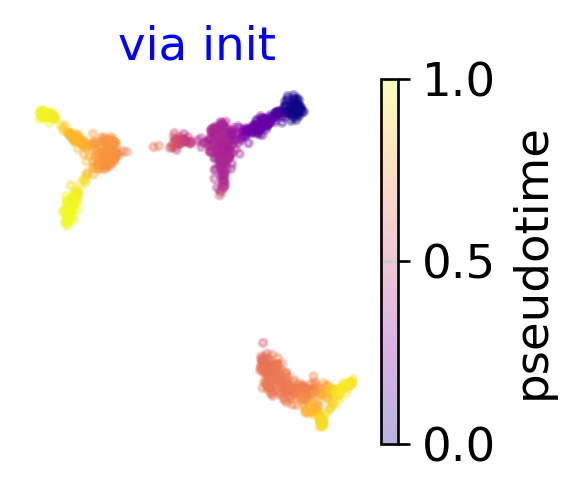

In [6]:
em2 = via_atlas_emb(via_object=v0,init_pos='via')
# optionally use UMAP/Phate/tsne 
# embedding = umap.UMAP().fit_transform(adata_counts.obsm['X_pca'][:, 0:10]) #if you wish, you can use a precomputed embedding (umap, t-sne)

f,ax=plot_scatter(embedding=em2, labels=v0.single_cell_pt_markov, cmap = 'plasma', title='via init')
f.set_size_inches(2,2)

2025-05-18 13:21:19.501876	Commencing Via-MDS
2025-05-18 13:21:19.501956	Resetting n_milestones to 1000 as n_samples > original n_milestones
minrowznormed -0.030169163
2025-05-18 13:21:19.869622	Start computing with diffusion power:1
2025-05-18 13:21:19.885648	Starting MDS on milestone
2025-05-18 13:21:21.098558	End computing mds with diffusion power:1
2025-05-18 13:21:21.138059	Commencing Via-MDS
2025-05-18 13:21:21.138109	Resetting n_milestones to 1000 as n_samples > original n_milestones
minrowznormed -0.030169163
2025-05-18 13:21:21.501922	Start computing with diffusion power:1
2025-05-18 13:21:21.514677	Starting MDS on milestone
2025-05-18 13:21:22.086995	End computing mds with diffusion power:1


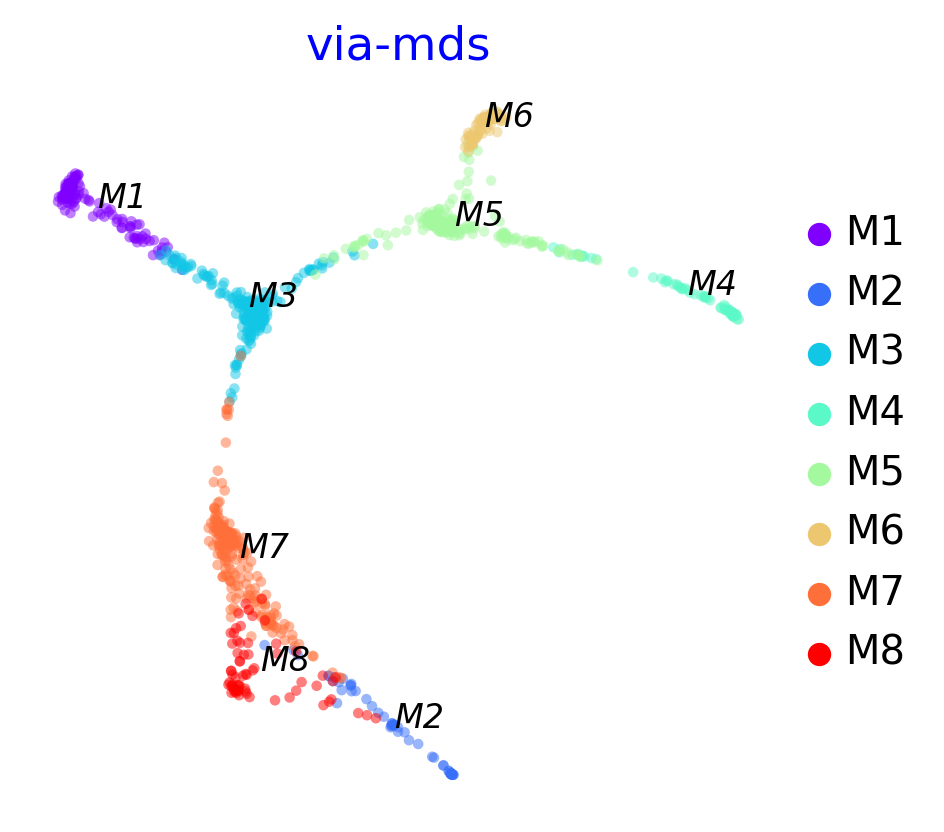

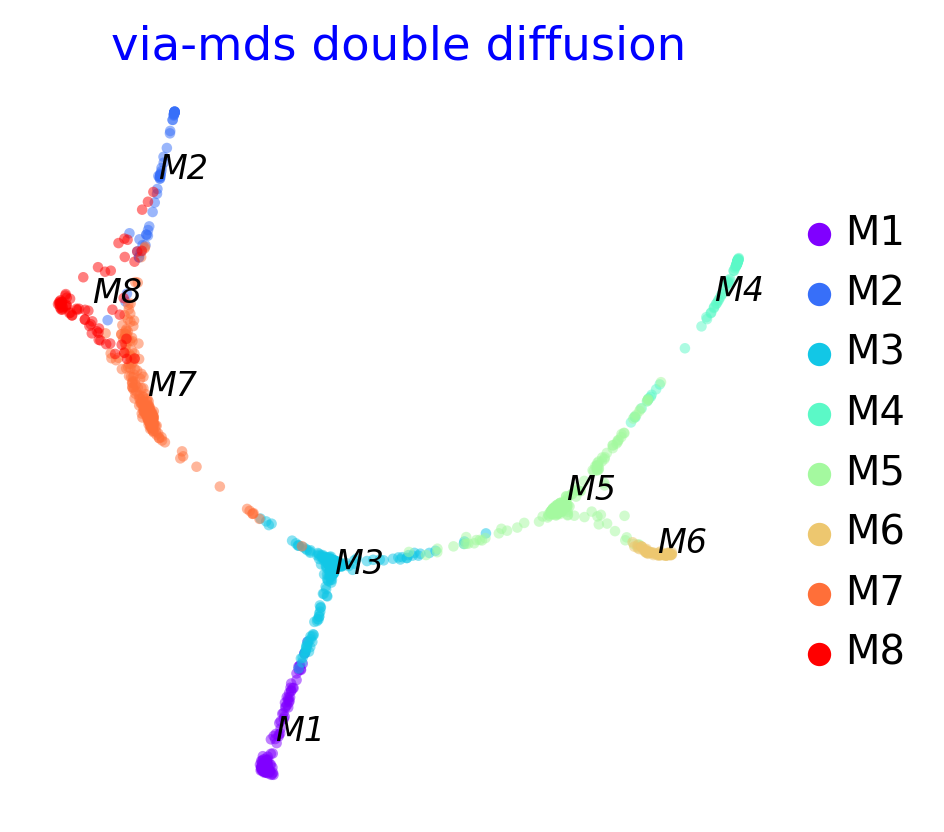

In [8]:
via_mds_embedding1 = via_mds(via_object=v0)
f, ax = plot_scatter(embedding=via_mds_embedding1, labels=v0.true_label, s=10, alpha=0.5, title='via-mds')

via_mds_embedding2 = via_mds(via_object=v0, double_diffusion = True)
f, ax = plot_scatter(embedding=via_mds_embedding2, labels=v0.true_label, s=10, alpha=0.5,title='via-mds double diffusion')


## Vector field

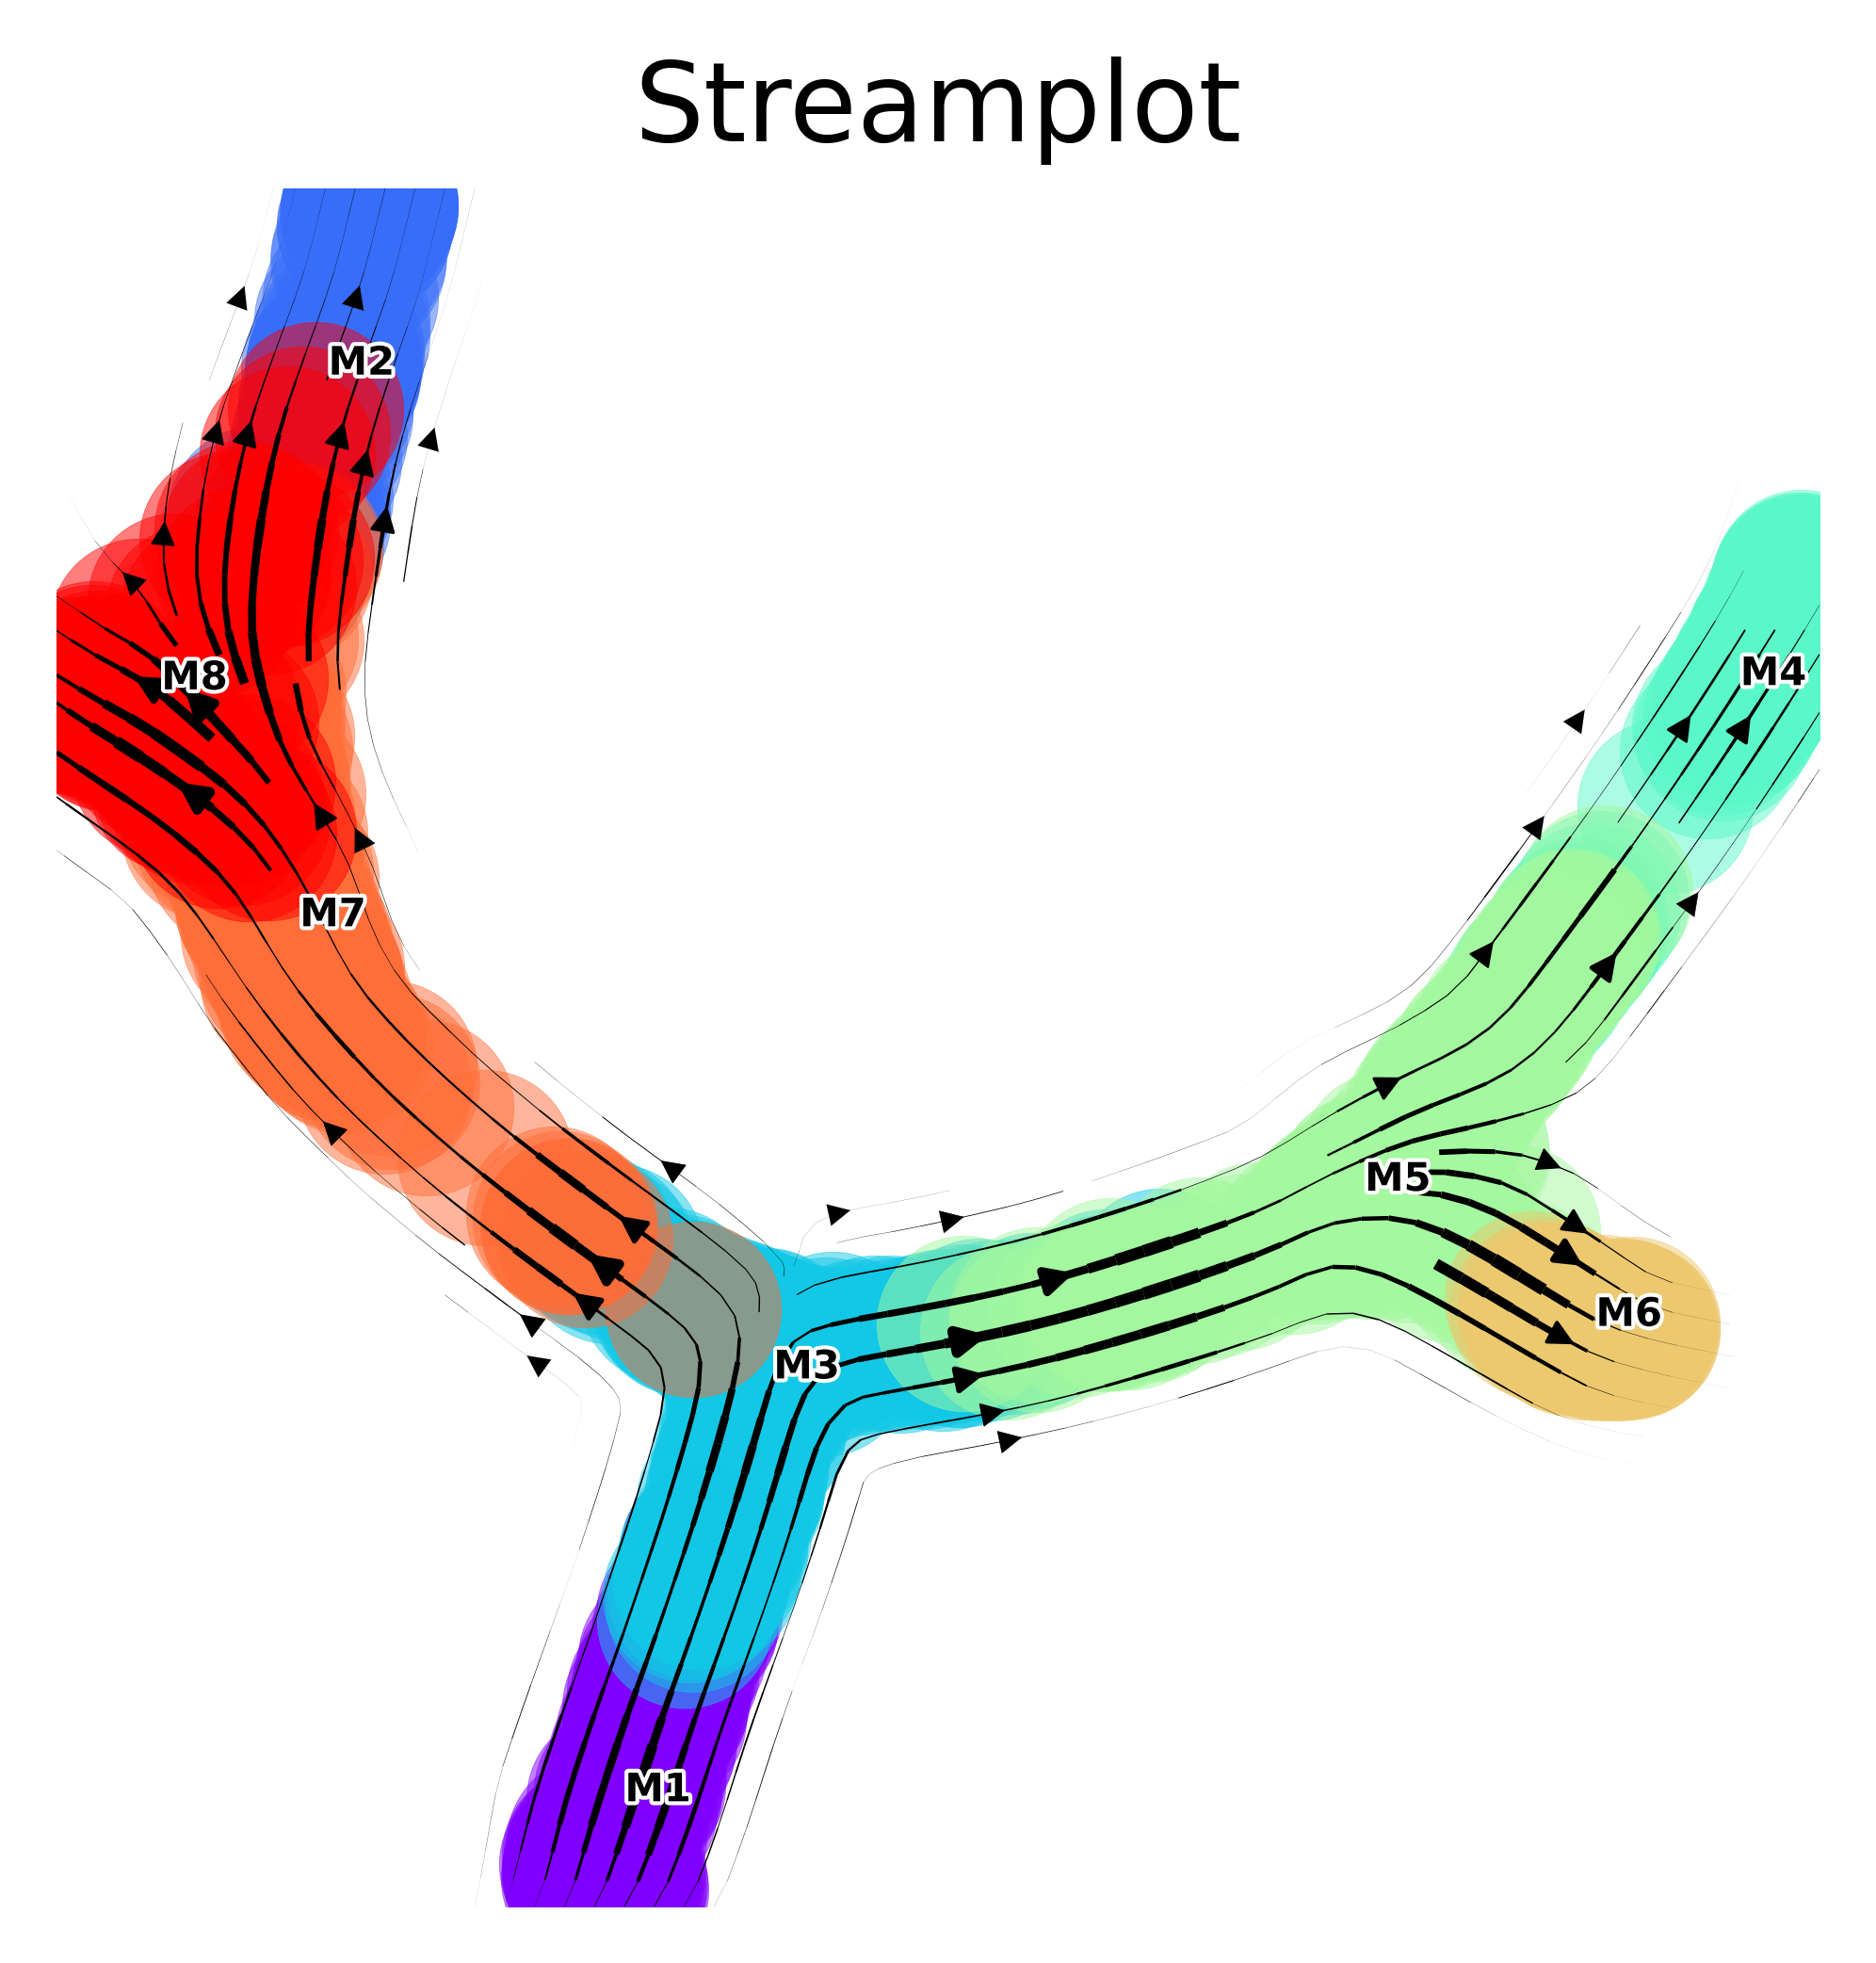

In [9]:
#default parameters:
# scatter_size=500
# scatter_alpha=0.5
# marker_edgewidth=0.1, outline of scatter points
# density_stream = 2, spacing between field lines
# smooth_transition=1,smoothing of transition matrix over neighbors of neighbors
# color_scheme = 'annotation', corresponds to true_labels  (cell types) provided. Can also be set to 'cluster' and 'time' and 'other'
# add_outline_clusters=False
# other_labels = [] provide a list of values for each cell corresponding to the value / annotation you wish to plot
v0.embedding = via_mds_embedding2
f, ax = via_streamplot(v0)
f.set_size_inches(4,4)

## Animate streamplot 

In [ ]:
animate_streamplot(v0, embedding=via_mds_embedding2, scatter_size=800, scatter_alpha=0.15, density_grid=2,  saveto='plots/test_toy3.gif' )


In [ ]:
with open('plots/test_toy3.gif','rb') as file:
    display(Image(file.read()))